In [2]:
import numpy as np
import pandas as pd
import random
from sklearn.datasets import make_classification

In [3]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [4]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.721821,-0.559645,-0.557556,-1.993885,-0.288671,0
1,-0.390478,1.470186,0.730225,-0.037215,1.306082,1
2,0.926449,-1.055626,1.045937,-0.343259,1.399115,0
3,-0.114265,1.975738,-0.896068,-1.631677,4.352963,1
4,1.997126,0.374994,-1.342669,-0.757796,0.004857,1


In [5]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [6]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [7]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [8]:
df1 = combined_sampling(df,0.5,0.5)

In [9]:
df2 = combined_sampling(df,0.5,0.5)

In [10]:
df3 = combined_sampling(df,0.5,0.5)

In [11]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col3', 'col2', 'target'], dtype='str')
Index(['col5', 'col4', 'target'], dtype='str')
Index(['col2', 'col5', 'target'], dtype='str')


In [12]:
df3

,col2,col5,target
18,-0.280550,0.337287,0
38,-3.529953,0.454879,0
39,-0.967014,1.458553,0
7,-2.144998,0.876995,0
59,1.416556,1.151155,1
55,-1.071768,0.575101,0
15,1.186719,0.658534,1
41,1.727357,1.519086,1
15,1.186719,0.658534,1
31,1.434494,2.508598,1


In [13]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [14]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [15]:
from sklearn.tree import plot_tree

[Text(0.38461538461538464, 0.9, 'x[1] <= 0.07\ngini = 0.499\nsamples = 50\nvalue = [24, 26]'),
 Text(0.15384615384615385, 0.7, 'x[0] <= -0.98\ngini = 0.091\nsamples = 21\nvalue = [20, 1]'),
 Text(0.2692307692307693, 0.8, 'True  '),
 Text(0.07692307692307693, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.23076923076923078, 0.5, 'gini = 0.0\nsamples = 20\nvalue = [20, 0]'),
 Text(0.6153846153846154, 0.7, 'x[0] <= 0.157\ngini = 0.238\nsamples = 29\nvalue = [4, 25]'),
 Text(0.5, 0.8, '  False'),
 Text(0.38461538461538464, 0.5, 'x[1] <= 1.118\ngini = 0.091\nsamples = 21\nvalue = [1, 20]'),
 Text(0.3076923076923077, 0.3, 'gini = 0.0\nsamples = 11\nvalue = [0, 11]'),
 Text(0.46153846153846156, 0.3, 'x[1] <= 1.145\ngini = 0.18\nsamples = 10\nvalue = [1, 9]'),
 Text(0.38461538461538464, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.5384615384615384, 0.1, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.8461538461538461, 0.5, 'x[1] <= 1.279\ngini = 0.469\nsamples = 8\nva

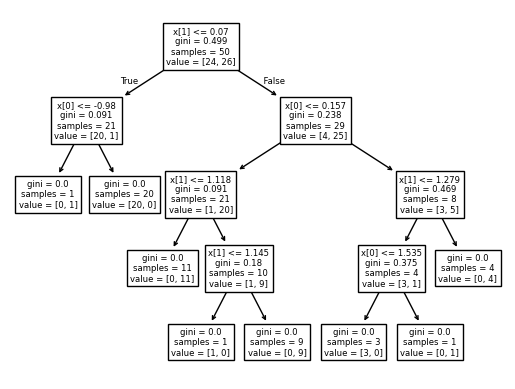

In [16]:
plot_tree(clf1)

[Text(0.575, 0.9375, 'x[0] <= 1.139\ngini = 0.487\nsamples = 50\nvalue = [21.0, 29.0]'),
 Text(0.35, 0.8125, 'x[0] <= 0.81\ngini = 0.485\nsamples = 29\nvalue = [17, 12]'),
 Text(0.46249999999999997, 0.875, 'True  '),
 Text(0.25, 0.6875, 'x[0] <= 0.694\ngini = 0.499\nsamples = 21\nvalue = [10, 11]'),
 Text(0.2, 0.5625, 'x[0] <= -0.036\ngini = 0.484\nsamples = 17\nvalue = [10, 7]'),
 Text(0.1, 0.4375, 'x[0] <= -0.538\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.05, 0.3125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.15, 0.3125, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.3, 0.4375, 'x[1] <= 0.104\ngini = 0.375\nsamples = 12\nvalue = [9, 3]'),
 Text(0.25, 0.3125, 'x[1] <= -0.455\ngini = 0.18\nsamples = 10\nvalue = [9, 1]'),
 Text(0.2, 0.1875, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.3, 0.1875, 'x[0] <= 0.376\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.25, 0.0625, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.35, 0.0625, 'gini = 0.0\nsampl

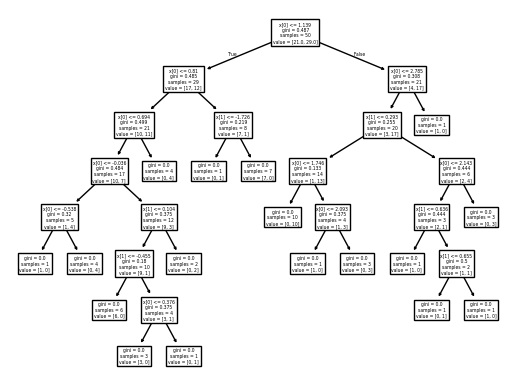

In [17]:
plot_tree(clf2)

[Text(0.5, 0.9, 'x[0] <= 0.271\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.3333333333333333, 0.7, 'gini = 0.0\nsamples = 21\nvalue = [21, 0]'),
 Text(0.41666666666666663, 0.8, 'True  '),
 Text(0.6666666666666666, 0.7, 'x[0] <= 1.186\ngini = 0.285\nsamples = 29\nvalue = [5, 24]'),
 Text(0.5833333333333333, 0.8, '  False'),
 Text(0.5, 0.5, 'x[1] <= 0.983\ngini = 0.459\nsamples = 14\nvalue = [5, 9]'),
 Text(0.3333333333333333, 0.3, 'x[0] <= 1.149\ngini = 0.18\nsamples = 10\nvalue = [1, 9]'),
 Text(0.16666666666666666, 0.1, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.5, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6666666666666666, 0.3, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.8333333333333334, 0.5, 'gini = 0.0\nsamples = 15\nvalue = [0, 15]')]

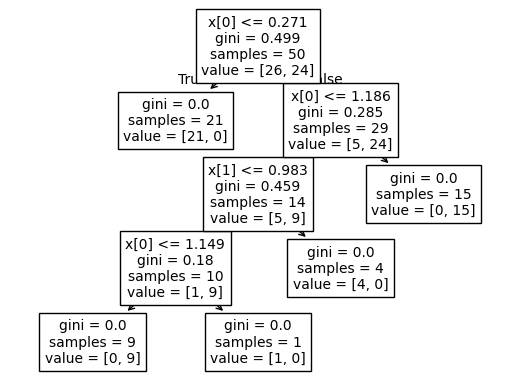

In [18]:
plot_tree(clf3)

In [19]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

d:\PENDRIVE 32 GB\Game\AI_PROJECTS\Machine Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [20]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

d:\PENDRIVE 32 GB\Game\AI_PROJECTS\Machine Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [21]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

d:\PENDRIVE 32 GB\Game\AI_PROJECTS\Machine Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [22]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
58,1.942695,-0.340936,1.167322,-1.200144,0.703613,0
86,-1.118047,1.437629,-0.247468,-1.673930,1.417633,1
73,3.747400,0.978536,-1.029830,-0.061323,1.713334,0
7,-0.569962,-2.144998,2.305755,-1.327661,0.876995,0
39,2.728613,-0.967014,-0.769049,-1.655184,1.458553,0
69,0.241395,-2.422135,1.284146,-1.622606,-0.267864,0
57,2.534090,1.123870,-1.163198,-0.147736,0.309410,0
73,3.747400,0.978536,-1.029830,-0.061323,1.713334,0
86,-1.118047,1.437629,-0.247468,-1.673930,1.417633,1
7,-0.569962,-2.144998,2.305755,-1.327661,0.876995,0
